<ipython-input-4-01cc20552962>:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(frd_files))


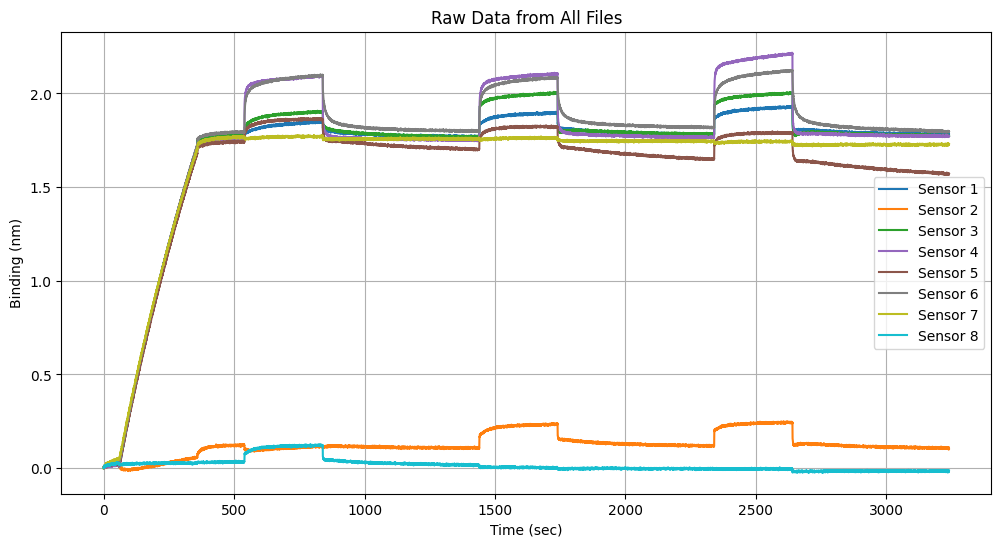

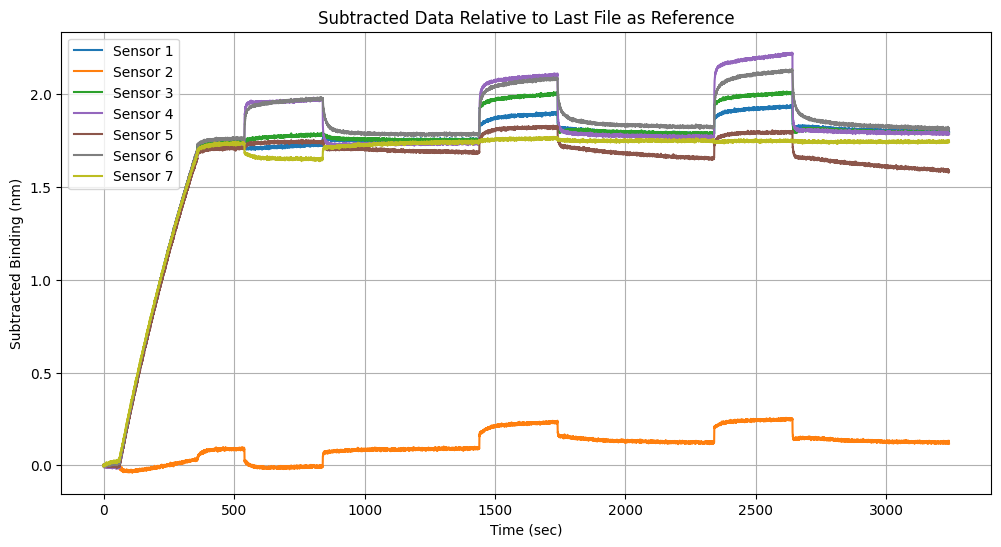

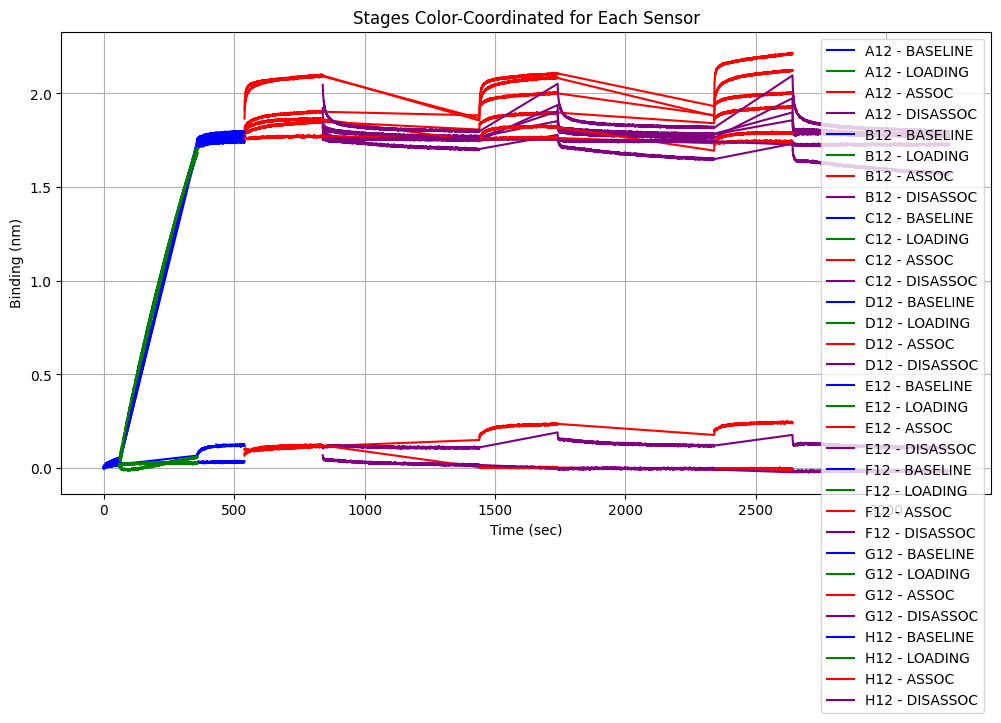

In [ ]:
import xml.etree.ElementTree as ET
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Function to decode base64 encoded data
def decode_base64(data):
    decoded_bytes = base64.b64decode(data)
    return np.frombuffer(decoded_bytes, dtype=np.float32)

# Function to process .frd files and extract necessary data
def process_frd_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()
    root = ET.fromstring(content)

    all_data = []
    exp_info = root.find('.//ExperimentInfo')
    sensor_name = exp_info.find('.//SensorName').text if exp_info.find('.//SensorName') is not None else "Unknown"

    for step in root.findall(".//Step"):
        step_type = step.find('.//StepType').text
        step_name = step.find('.//StepName').text
        time_data_encoded = step.find('.//AssayXData').text
        binding_data_encoded = step.find('.//AssayYData').text

        time_data = decode_base64(time_data_encoded)
        binding_data = decode_base64(binding_data_encoded)

        for t, b in zip(time_data, binding_data):
            all_data.append([sensor_name, step_name, step_type, t, b])

    return pd.DataFrame(all_data, columns=['Sensor', 'Step Name', 'Step Type', 'Time (sec)', 'Binding (nm)'])

# Directory where the .frd files are stored
directory_path = '/content/Untitled Folder'
# List all .frd files in the directory
frd_files = [os.path.join(directory_path, f"240712_{str(i).zfill(3)}.frd") for i in range(1, 9)]

# Process all .frd files
data_frames = [process_frd_file(f) for f in frd_files]

# Combine all DataFrames into one for easier manipulation
combined_df = pd.concat(data_frames, ignore_index=True)

# Plot 1: Raw data from all sensors
plt.figure(figsize=(12, 6))
colors = plt.cm.get_cmap('tab10', len(frd_files))
for i, df in enumerate(data_frames):
    plt.plot(df['Time (sec)'], df['Binding (nm)'], label=f'Sensor {i+1}', color=colors(i))

plt.title('Raw Data from All Files')
plt.xlabel('Time (sec)')
plt.ylabel('Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Subtracted data (using the last file as reference)
reference_data = data_frames[-1]

plt.figure(figsize=(12, 6))
for i, df in enumerate(data_frames[:-1]):
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))

plt.title('Subtracted Data Relative to Last File as Reference')
plt.xlabel('Time (sec)')
plt.ylabel('Subtracted Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Color-coordinated stages for each sensor
plt.figure(figsize=(12, 6))
stage_colors = {'BASELINE': 'blue', 'LOADING': 'green', 'ASSOC': 'red', 'DISASSOC': 'purple'}
for sensor in combined_df['Sensor'].unique():
    sensor_data = combined_df[combined_df['Sensor'] == sensor]
    for stage, color in stage_colors.items():
        stage_data = sensor_data[sensor_data['Step Type'] == stage]
        plt.plot(stage_data['Time (sec)'], stage_data['Binding (nm)'], label=f'{sensor} - {stage}', color=color)
plt.title('Stages Color-Coordinated for Each Sensor')
plt.xlabel('Time (sec)')
plt.ylabel('Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install xml.etree.ElementTree base64 numpy pandas matplotlib


ERROR: Could not find a version that satisfies the requirement xml.etree.ElementTree (from versions: none)
ERROR: No matching distribution found for xml.etree.ElementTree


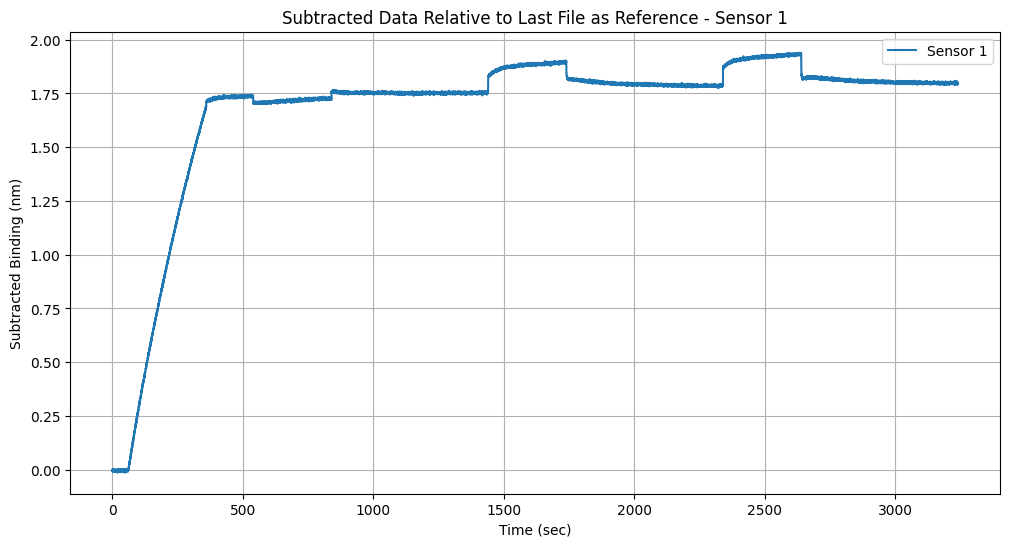

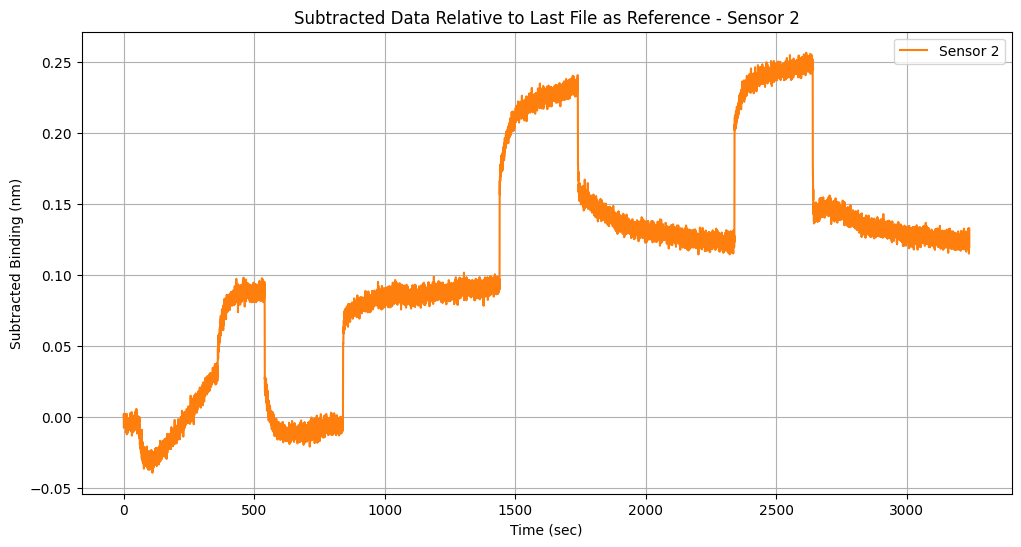

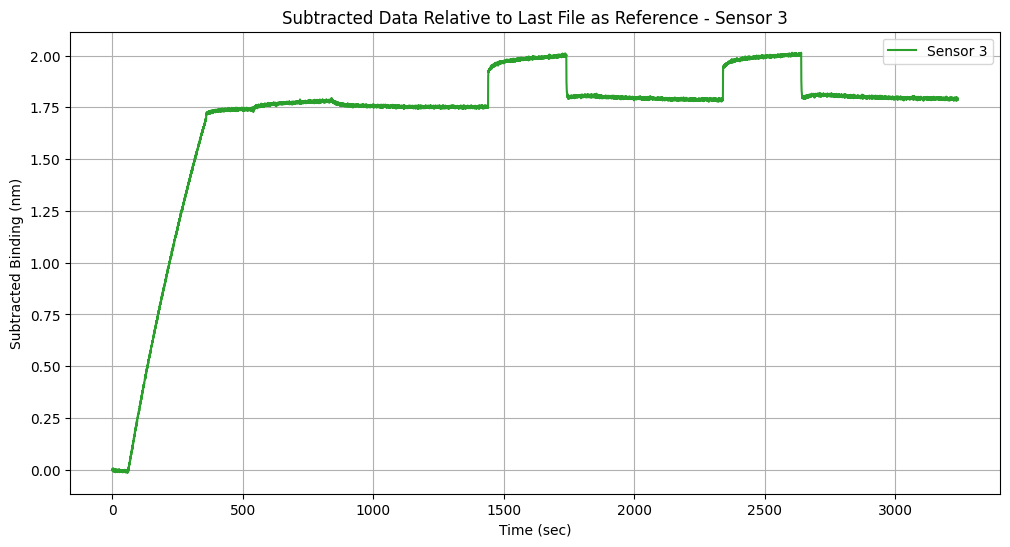

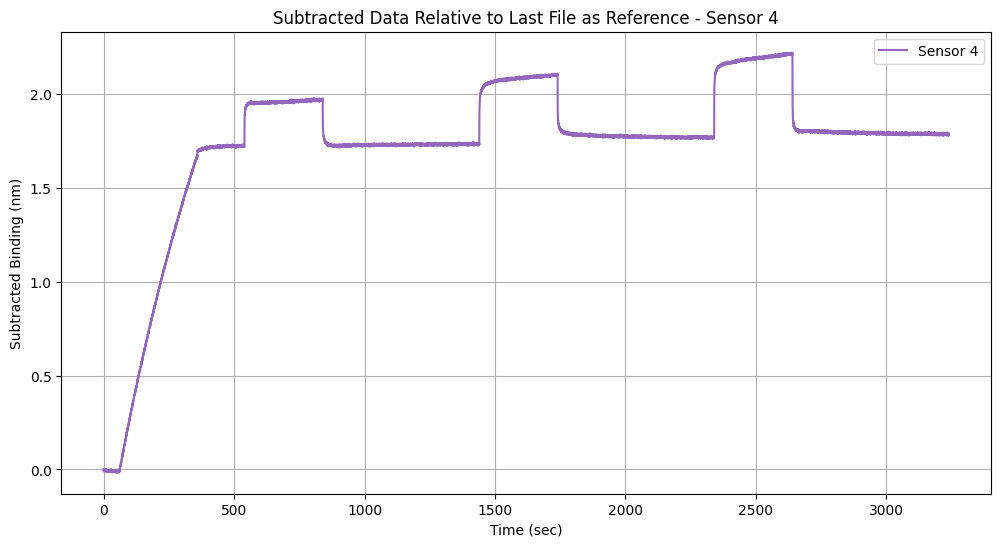

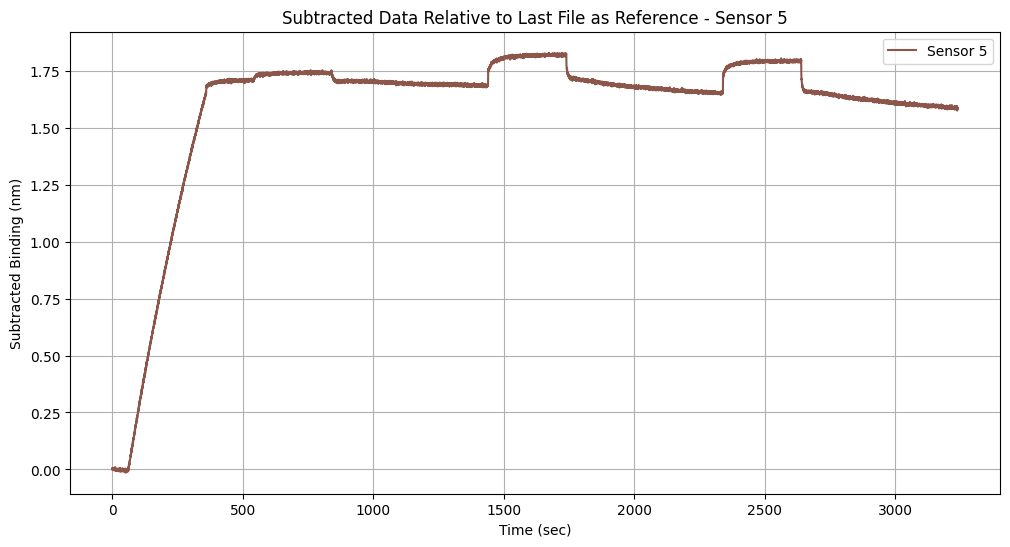

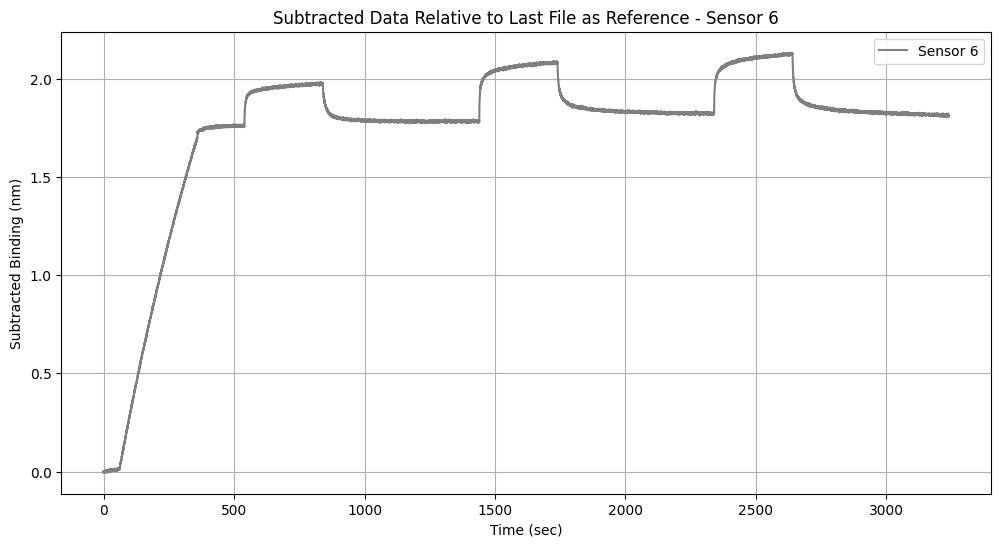

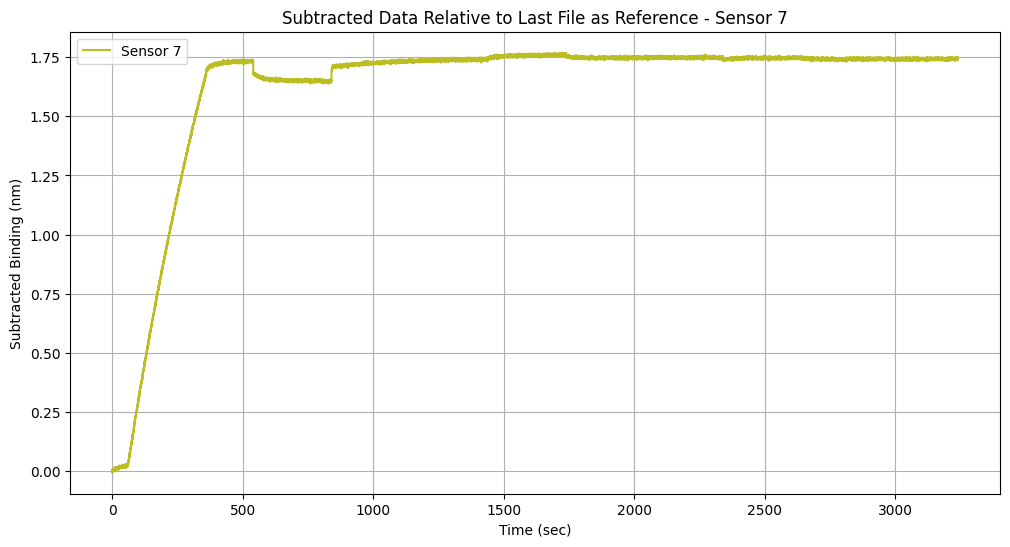

In [ ]:
# Plot Subtracted Data: Each subtracted dataset in its own graph
reference_data = data_frames[-1]  # Last file as the reference

for i, df in enumerate(data_frames[:-1]):  # Skip the last file as it is the reference
    plt.figure(figsize=(12, 6))  # Create a new figure for each plot
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))
    plt.title(f'Subtracted Data Relative to Last File as Reference - Sensor {i+1}')
    plt.xlabel('Time (sec)')
    plt.ylabel('Subtracted Binding (nm)')
    plt.legend()
    plt.grid(True)
    plt.show()


Failed to fit data for Sensor 1: 'Concentration'
Failed to fit data for Sensor 2: 'Concentration'
Failed to fit data for Sensor 3: 'Concentration'
Failed to fit data for Sensor 4: 'Concentration'
Failed to fit data for Sensor 5: 'Concentration'
Failed to fit data for Sensor 6: 'Concentration'
Failed to fit data for Sensor 7: 'Concentration'
Failed to fit data for Sensor 8: 'Concentration'
Kd values for all sensors: {}


<ipython-input-10-7618b7eb20ad>:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(frd_files))


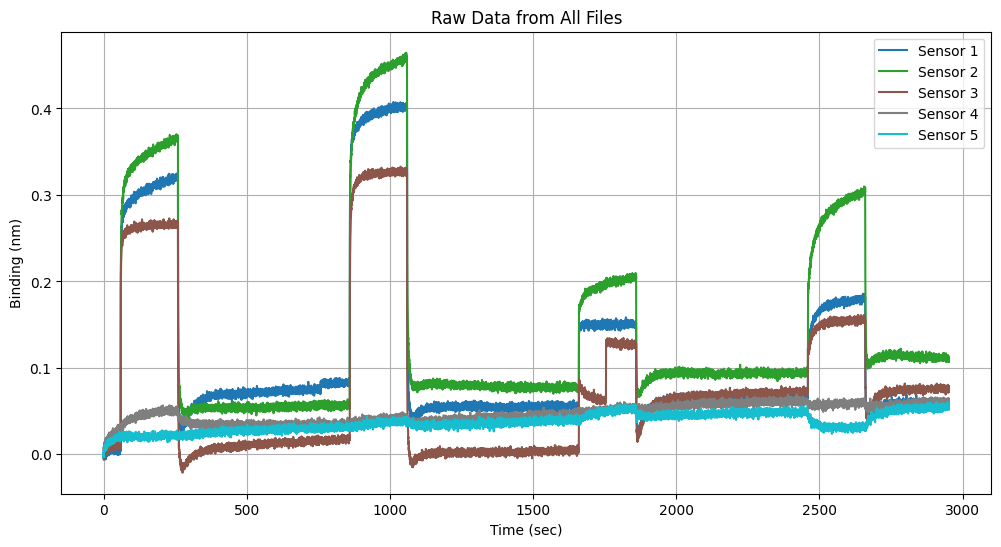

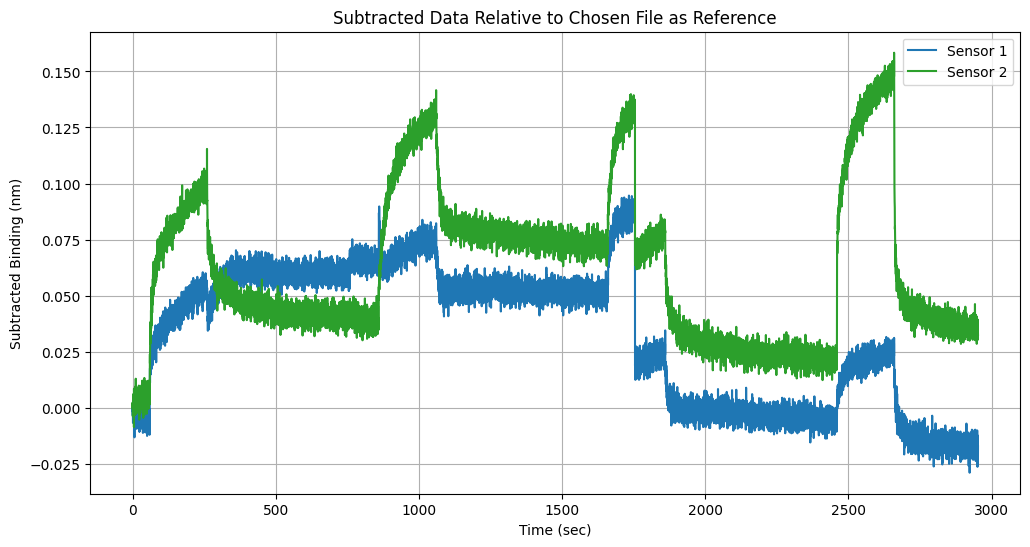

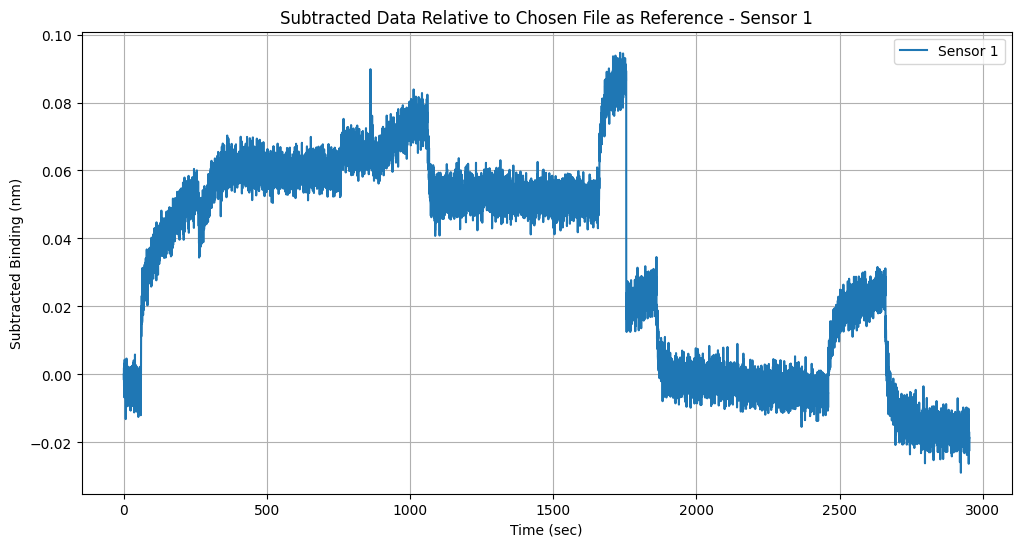

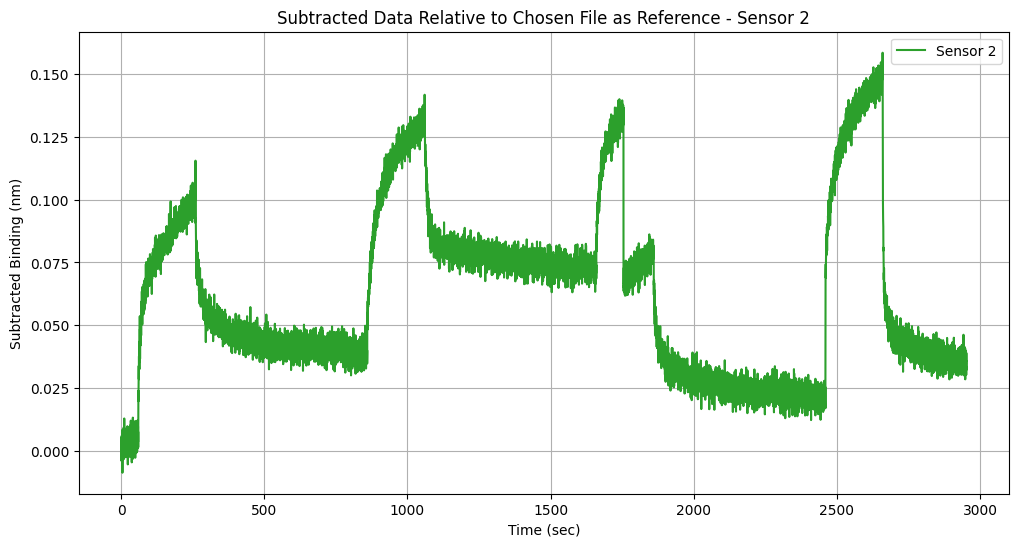

In [ ]:
import xml.etree.ElementTree as ET
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Function to decode base64 encoded data
def decode_base64(data):
    decoded_bytes = base64.b64decode(data)
    return np.frombuffer(decoded_bytes, dtype=np.float32)

# Function to process .frd files and extract necessary data
def process_frd_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()
    root = ET.fromstring(content)

    all_data = []
    exp_info = root.find('.//ExperimentInfo')
    sensor_name = exp_info.find('.//SensorName').text if exp_info.find('.//SensorName') is not None else "Unknown"

    for step in root.findall(".//Step"):
        step_type = step.find('.//StepType').text
        step_name = step.find('.//StepName').text
        time_data_encoded = step.find('.//AssayXData').text
        binding_data_encoded = step.find('.//AssayYData').text

        time_data = decode_base64(time_data_encoded)
        binding_data = decode_base64(binding_data_encoded)

        for t, b in zip(time_data, binding_data):
            all_data.append([sensor_name, step_name, step_type, t, b])

    return pd.DataFrame(all_data, columns=['Sensor', 'Step Name', 'Step Type', 'Time (sec)', 'Binding (nm)'])

# Directory where the .frd files are stored
directory_path = '/content/EXP1'
# List specified .frd files
frd_files = [os.path.join(directory_path, file) for file in ['130615_001.frd', '130615_002.frd', '130615_003.frd', '130615_007.frd', '130615_008.frd']]

# Process all .frd files
data_frames = [process_frd_file(f) for f in frd_files]

# Combine all DataFrames into one for easier manipulation
combined_df = pd.concat(data_frames, ignore_index=True)

# Display the combined data
combined_df.head()

# Set the reference file index programmatically
reference_file_index = 2  # Index 2 corresponds to '130615_003.frd'
reference_data = data_frames[reference_file_index]

# Plot 1: Raw data from all sensors
plt.figure(figsize=(12, 6))
colors = plt.cm.get_cmap('tab10', len(frd_files))
for i, df in enumerate(data_frames):
    plt.plot(df['Time (sec)'], df['Binding (nm)'], label=f'Sensor {i+1}', color=colors(i))

plt.title('Raw Data from All Files')
plt.xlabel('Time (sec)')
plt.ylabel('Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Subtracted data (using the chosen file as reference), excluding files 7 and 8
plt.figure(figsize=(12, 6))
for i, df in enumerate(data_frames):
    if i == reference_file_index or i in [3, 4]:  # Skip the reference file and files 7 and 8
        continue
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))

plt.title('Subtracted Data Relative to Chosen File as Reference')
plt.xlabel('Time (sec)')
plt.ylabel('Subtracted Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Subtracted Data: Each subtracted dataset in its own graph, excluding files 7 and 8
for i, df in enumerate(data_frames):
    if i == reference_file_index or i in [3, 4]:  # Skip the reference file and files 7 and 8
        continue
    plt.figure(figsize=(12, 6))  # Create a new figure for each plot
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))
    plt.title(f'Subtracted Data Relative to Chosen File as Reference - Sensor {i+1}')
    plt.xlabel('Time (sec)')
    plt.ylabel('Subtracted Binding (nm)')
    plt.legend()
    plt.grid(True)
    plt.show()


<ipython-input-11-0809ae1d2451>:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(frd_files))


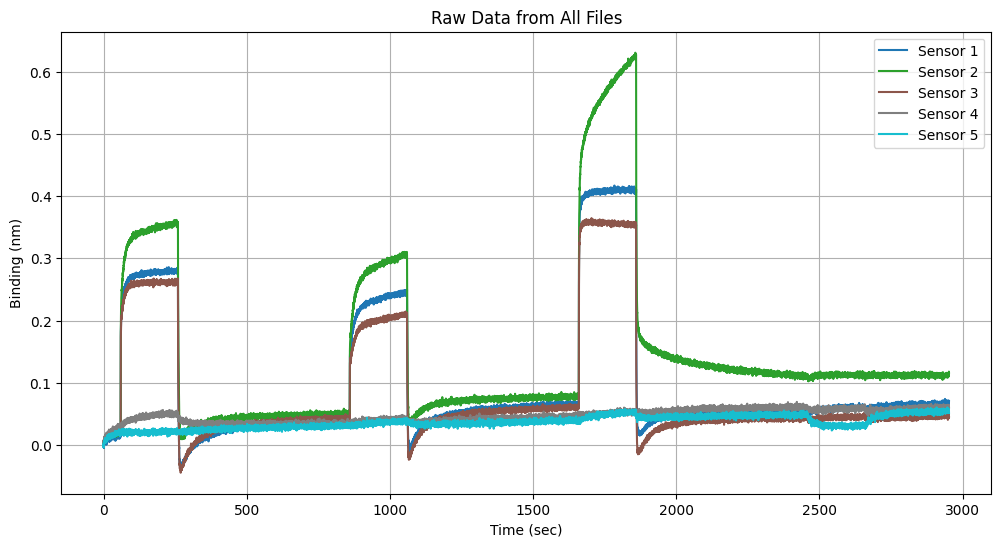

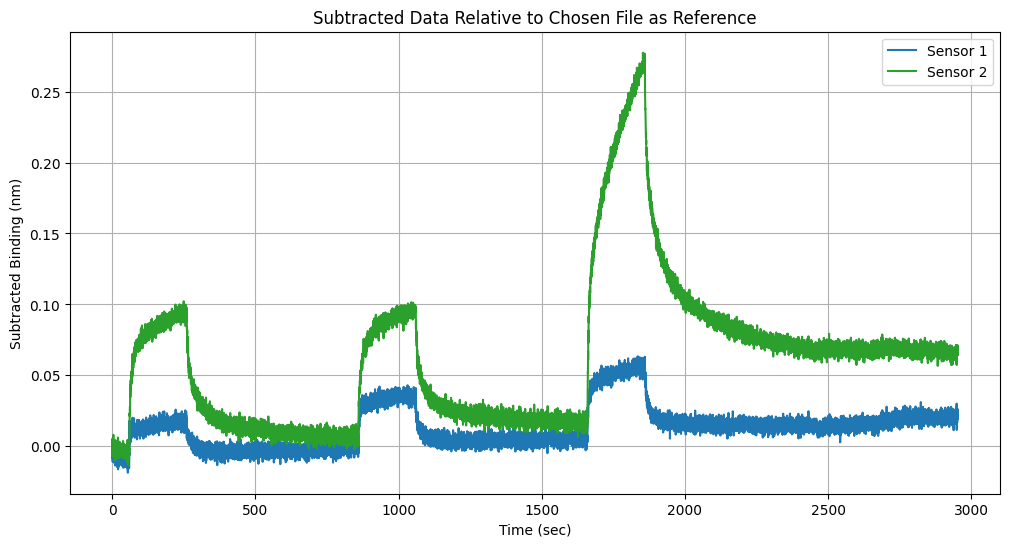

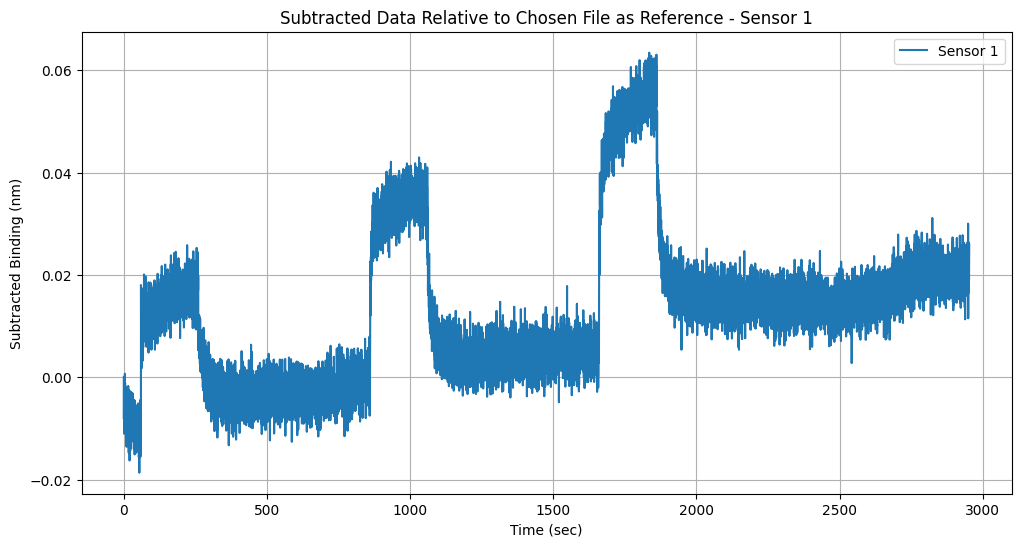

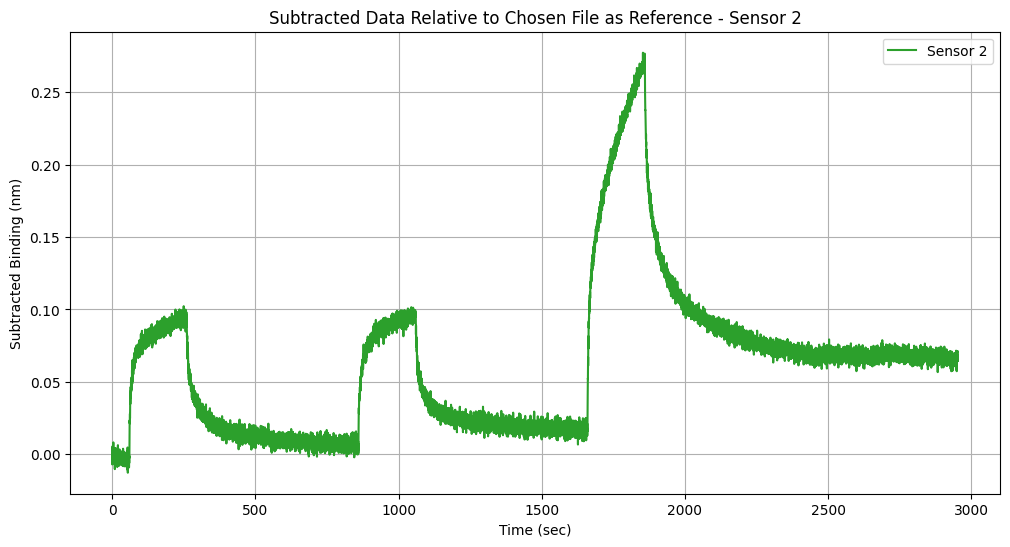

In [ ]:
import xml.etree.ElementTree as ET
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Function to decode base64 encoded data
def decode_base64(data):
    decoded_bytes = base64.b64decode(data)
    return np.frombuffer(decoded_bytes, dtype=np.float32)

# Function to process .frd files and extract necessary data
def process_frd_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()
    root = ET.fromstring(content)

    all_data = []
    exp_info = root.find('.//ExperimentInfo')
    sensor_name = exp_info.find('.//SensorName').text if exp_info.find('.//SensorName') is not None else "Unknown"

    for step in root.findall(".//Step"):
        step_type = step.find('.//StepType').text
        step_name = step.find('.//StepName').text
        time_data_encoded = step.find('.//AssayXData').text
        binding_data_encoded = step.find('.//AssayYData').text

        time_data = decode_base64(time_data_encoded)
        binding_data = decode_base64(binding_data_encoded)

        for t, b in zip(time_data, binding_data):
            all_data.append([sensor_name, step_name, step_type, t, b])

    return pd.DataFrame(all_data, columns=['Sensor', 'Step Name', 'Step Type', 'Time (sec)', 'Binding (nm)'])

# Directory where the .frd files are stored
directory_path = '/content/EXP2'
# List specified .frd files
frd_files = [os.path.join(directory_path, file) for file in ['130615_004.frd', '130615_005.frd', '130615_006.frd', '130615_007.frd', '130615_008.frd']]

# Process all .frd files
data_frames = [process_frd_file(f) for f in frd_files]

# Combine all DataFrames into one for easier manipulation
combined_df = pd.concat(data_frames, ignore_index=True)

# Display the combined data
combined_df.head()

# Set the reference file index programmatically
reference_file_index = 2  # Index 2 corresponds to '130615_003.frd'
reference_data = data_frames[reference_file_index]

# Plot 1: Raw data from all sensors
plt.figure(figsize=(12, 6))
colors = plt.cm.get_cmap('tab10', len(frd_files))
for i, df in enumerate(data_frames):
    plt.plot(df['Time (sec)'], df['Binding (nm)'], label=f'Sensor {i+1}', color=colors(i))

plt.title('Raw Data from All Files')
plt.xlabel('Time (sec)')
plt.ylabel('Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Subtracted data (using the chosen file as reference), excluding files 7 and 8
plt.figure(figsize=(12, 6))
for i, df in enumerate(data_frames):
    if i == reference_file_index or i in [3, 4]:  # Skip the reference file and files 7 and 8
        continue
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))

plt.title('Subtracted Data Relative to Chosen File as Reference')
plt.xlabel('Time (sec)')
plt.ylabel('Subtracted Binding (nm)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Subtracted Data: Each subtracted dataset in its own graph, excluding files 7 and 8
for i, df in enumerate(data_frames):
    if i == reference_file_index or i in [3, 4]:  # Skip the reference file and files 7 and 8
        continue
    plt.figure(figsize=(12, 6))  # Create a new figure for each plot
    interpolated_ref = np.interp(df['Time (sec)'], reference_data['Time (sec)'], reference_data['Binding (nm)'])
    subtracted_data = df['Binding (nm)'] - interpolated_ref
    plt.plot(df['Time (sec)'], subtracted_data, label=f'Sensor {i+1}', color=colors(i))
    plt.title(f'Subtracted Data Relative to Chosen File as Reference - Sensor {i+1}')
    plt.xlabel('Time (sec)')
    plt.ylabel('Subtracted Binding (nm)')
    plt.legend()
    plt.grid(True)
    plt.show()
